In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Arumu\Downloads\zomato\zomato.csv")
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [4]:
df.shape

(56252, 13)

In [5]:
df.isnull().sum()

address                           17
name                              16
online_order                      19
book_table                        58
rate                            7838
votes                             78
phone                           1296
location                         126
rest_type                        338
dish_liked                     28225
cuisines                         203
approx_cost(for two people)      521
listed_in(type)                 4610
dtype: int64

In [8]:
df['rate'] = df['rate'].astype(str)

df['rate'] = df['rate'].str.replace("/5", "", regex=False)
df['rate'] = df['rate'].str.replace(" ", "", regex=False)

df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [9]:
df['rate'] = df['rate'].fillna(df['rate'].median())

In [11]:
print(df.columns)

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')


In [12]:
df.rename(columns={
    'approx_cost(for two people)': 'cost'
}, inplace=True)

In [13]:
df['cost']

0          800
1          800
2          800
3          300
4          600
         ...  
56247    1,500
56248      600
56249    2,000
56250    2,500
56251    1,500
Name: cost, Length: 56252, dtype: object

In [14]:
df['cost'] = df['cost'].astype(str)

df['cost'] = df['cost'].str.replace(",", "", regex=False)
df['cost'] = df['cost'].str.strip()

df['cost'] = pd.to_numeric(df['cost'], errors='coerce')

df['cost'] = df['cost'].fillna(df['cost'].median())

In [15]:
df['rate'] = df['rate'].astype(str)

df['rate'] = df['rate'].str.replace("/5", "", regex=False)
df['rate'] = df['rate'].str.replace(" ", "", regex=False)

df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df['rate'] = df['rate'].fillna(df['rate'].median())

In [16]:
df[['rate', 'cost']].head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   address          56235 non-null  object 
 1   name             56236 non-null  object 
 2   online_order     56233 non-null  object 
 3   book_table       56194 non-null  object 
 4   rate             56252 non-null  float64
 5   votes            56174 non-null  object 
 6   phone            54956 non-null  object 
 7   location         56126 non-null  object 
 8   rest_type        55914 non-null  object 
 9   dish_liked       28027 non-null  object 
 10  cuisines         56049 non-null  object 
 11  cost             56252 non-null  float64
 12  listed_in(type)  51642 non-null  object 
dtypes: float64(2), object(11)
memory usage: 5.6+ MB


In [17]:
df['votes'] = df['votes'].astype(str)

df['votes'] = df['votes'].str.replace(",", "", regex=False)
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

df['votes'] = df['votes'].fillna(0)

In [18]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   address          56235 non-null  object 
 1   name             56236 non-null  object 
 2   online_order     56233 non-null  object 
 3   book_table       56194 non-null  object 
 4   rate             56252 non-null  float64
 5   votes            56252 non-null  float64
 6   phone            54956 non-null  object 
 7   location         56126 non-null  object 
 8   rest_type        55914 non-null  object 
 9   dish_liked       28027 non-null  object 
 10  cuisines         56049 non-null  object 
 11  cost             56252 non-null  float64
 12  listed_in(type)  51642 non-null  object 
dtypes: float64(3), object(10)
memory usage: 5.6+ MB


address               17
name                  16
online_order          19
book_table            58
rate                   0
votes                  0
phone               1296
location             126
rest_type            338
dish_liked         28225
cuisines             203
cost                   0
listed_in(type)     4610
dtype: int64

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
import re

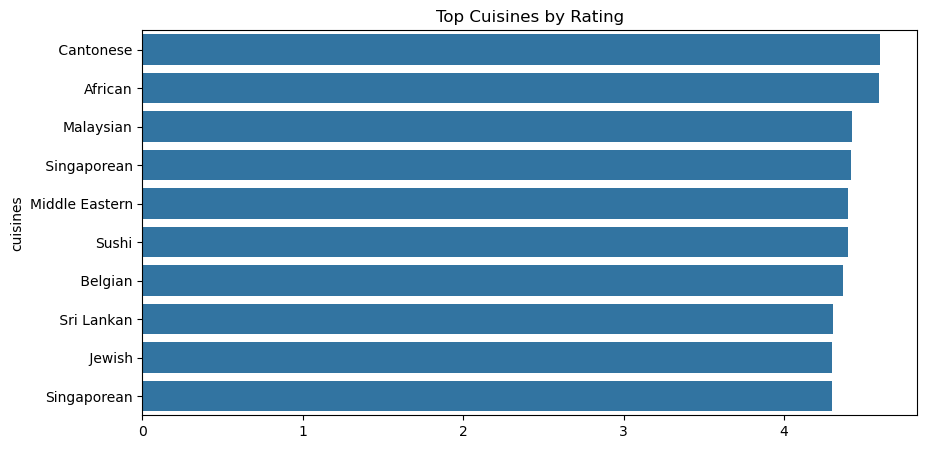

In [21]:
df['cuisines'] = df['cuisines'].fillna("Unknown")

cuisine_df = df.assign(cuisines=df['cuisines'].str.split(",")).explode('cuisines')

top_cuisines = cuisine_df.groupby('cuisines')['rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top Cuisines by Rating")
plt.show()

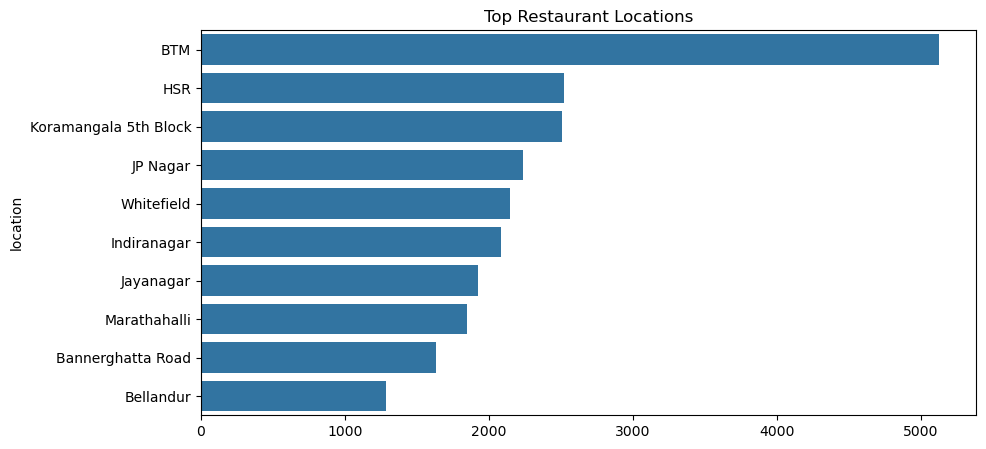

In [22]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top Restaurant Locations")
plt.show()

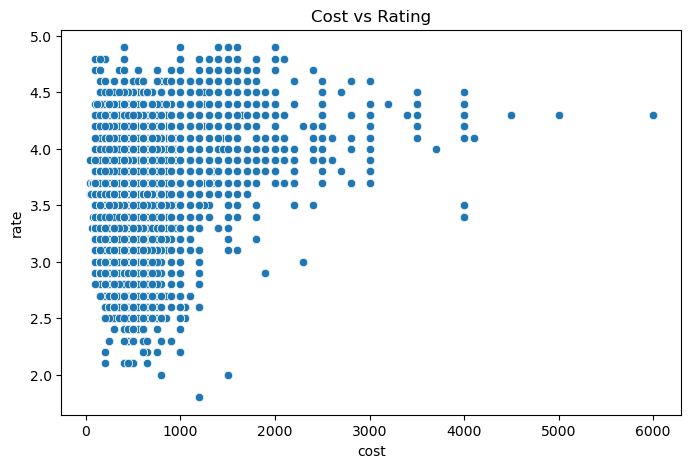

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='cost', y='rate')
plt.title("Cost vs Rating")
plt.show()

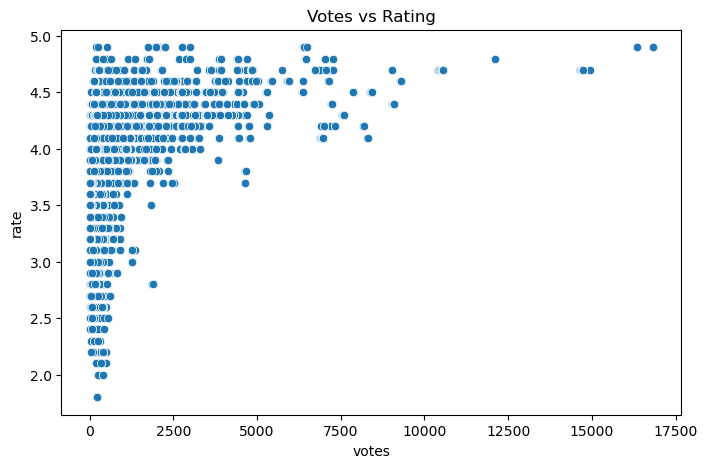

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='votes', y='rate')
plt.title("Votes vs Rating")
plt.show()

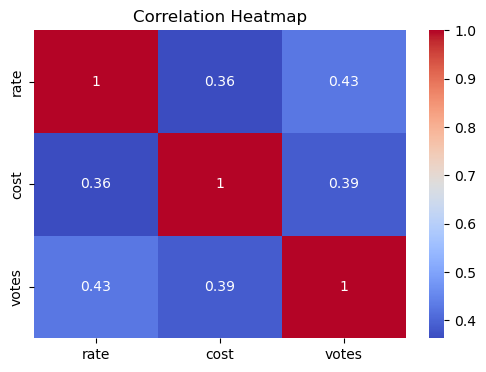

In [25]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['rate','cost','votes']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

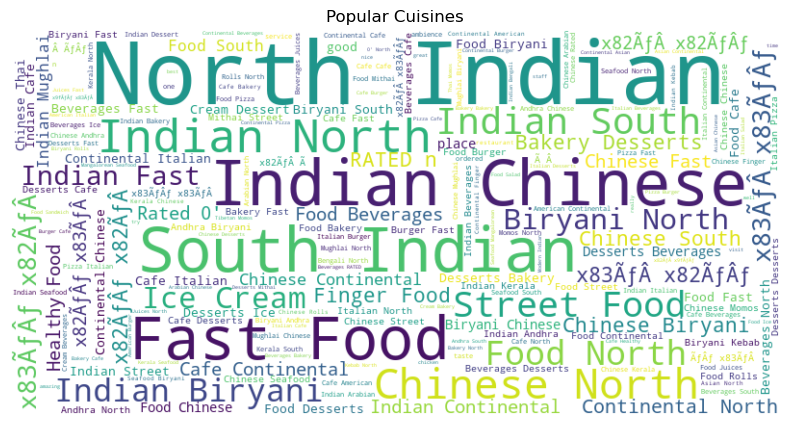

In [26]:
text = " ".join(df['cuisines'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Popular Cuisines")
plt.show()

In [27]:
print("Top rated restaurant name:", df.loc[df['rate'].idxmax(), 'name'])
print("Most common location:", df['location'].value_counts().idxmax())
print("Most popular cuisine:", df['cuisines'].value_counts().idxmax())
print("Average rating:", df['rate'].mean())
print("Average cost:", df['cost'].mean())

Top rated restaurant name: Byg Brewski Brewing Company
Most common location: BTM
Most popular cuisine: North Indian
Average rating: 3.7003324326246183
Average cost: 541.9447308540141
